# Multi-armed bandits

### Ten slot machines, a thousand pulls, and no way to learn without paying for it

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why exploring costs you money, what regret measures that reward does not, and four ways to trade the two off (greedy, epsilon-greedy, UCB1 and Thompson sampling), each written from scratch in NumPy |
| **You should already know** | Python and NumPy. A rough idea of what a probability distribution is. No prior reinforcement learning needed |
| **Environment** | A Bernoulli bandit, simulated in this notebook. No dataset, no gym, no RL library |
| **Runtime** | Under two minutes on a laptop CPU |
| **Next** | [11-03 Markov decision processes](../03-markov-decision-processes/) · [11-04 Q-learning](../04-q-learning/) |

---

## 1. The idea

Ten slot machines stand in a row. Each one pays either 1 or 0 when you pull it,
and each has its own fixed chance of paying. You do not know any of those
chances. You get a thousand pulls, one machine per pull, and you want as much
money as you can carry out.

That is the whole problem. There is no state to track, no sequence to plan, no
delayed consequence: what you pull now has no effect on what the machines will
do later. Take [Q-learning](../04-q-learning/) and remove everything except the
choice itself, and this is what is left over.

What is left over is the part that never goes away. To find out whether an arm
is good you have to pull it, and every pull spent finding out is a pull not
spent earning. That is the **explore-exploit tradeoff**, and there is no clever
engineering that makes it disappear. You can only manage it.

There are two ways to lose. Never explore, and you hand your whole budget to the
first machine that paid you twice in a row, which is very often not the best
one. Always explore, and you end up knowing all ten rates to three decimal
places while having earned the average of them.

I set the ten rates myself so that I can score every strategy against the truth.
The strategies never see them. All they ever see is a 0 or a 1 after each pull.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

# The ten arms. Two of them are close together at the top, which is what makes
# the problem hard: telling 0.65 from 0.60 takes a lot of pulls.
RATES = np.array([0.20, 0.35, 0.42, 0.50, 0.28, 0.60, 0.65, 0.33, 0.55, 0.45])
K = RATES.size
BEST = int(RATES.argmax())

RUNS, STEPS = 300, 1000     # 300 independent repeats of a 1000-pull session

print(f"{K} arms, {STEPS} pulls per session, {RUNS} independent sessions")
print(f"best arm is arm {BEST} at {RATES[BEST]:.2f}, "
      f"runner-up pays {np.sort(RATES)[-2]:.2f}")

10 arms, 1000 pulls per session, 300 independent sessions
best arm is arm 6 at 0.65, runner-up pays 0.60


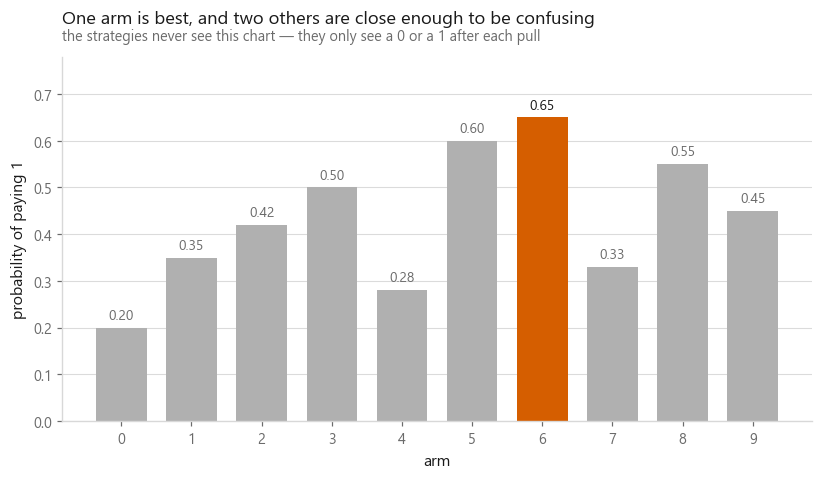

In [2]:
fig, ax = plt.subplots(figsize=(8.8, 4.3))

ax.bar(np.arange(K), RATES, color=style.spot(K, BEST), width=0.72)
for i, rate in enumerate(RATES):
    ax.text(i, rate + 0.012, f"{rate:.2f}", ha="center", va="bottom",
            fontsize=9, color=style.INK if i == BEST else style.MUTED)

ax.set_xticks(np.arange(K))
ax.set_xlabel("arm")
ax.set_ylabel("probability of paying 1")
ax.set_ylim(0, 0.78)
style.title(ax, "One arm is best, and two others are close enough to be confusing",
            "the strategies never see this chart — they only see a 0 or a 1 after each pull")
style.save(fig, FIG / "fig-01-arms.png")

## 2. Regret, the thing to minimise

The obvious score is total reward. It is a bad score, because it mostly measures
how generous the machines happen to be. Move every rate up by 0.2 and every
strategy earns more without having got any smarter.

So I score the gap instead. Write $p_i$ for the payout probability of arm $i$,
and $p^\star = \max_i p_i$ for the best one. If the strategy pulls arm $A_t$ at
step $t$, its **expected cumulative regret** after $T$ pulls is

$$L_T = \sum_{t=1}^{T} \left( p^\star - p_{A_t} \right)$$

This is the money left on the table by not already knowing which arm was best.
It starts at zero, it never decreases, and a strategy that has fully worked out
the answer stops adding to it.

Two details worth being explicit about. First, I score the *expected* gap
$p^\star - p_{A_t}$ rather than the realised reward. A strategy that pulls the
best arm and gets unlucky has made no mistake, and I do not want the coin flip
in the score. Second, regret is defined against a hindsight benchmark the
strategy could not have had. That is the point: it isolates the cost of not
knowing.

### What good looks like

The shape of the curve matters more than its height.

If a strategy keeps some fixed chance of pulling a bad arm forever, it pays a
fixed toll every step and its regret grows in a straight line. Linear regret is
the failure mode. What you want is a curve that **flattens**, regret still
rising, but more and more slowly, because bad pulls are getting rarer.

There is a floor on how flat it can get. Lai and Robbins proved in 1985 that any
strategy which does uniformly well across problems must pull each bad arm on the
order of $\log T$ times, so regret of order $\log T$ is the best available. You
cannot stop paying to explore. You can only pay less and less often.

In [3]:
class Bandit:
    """k arms. Arm i pays 1 with probability rates[i] and 0 otherwise.

    Every method is vectorised over `runs`, so all the independent sessions
    advance one step together. That is the only reason this notebook finishes in
    seconds rather than minutes.
    """

    def __init__(self, rates, runs, seed):
        self.rates = np.asarray(rates, dtype=float)
        self.k = self.rates.size
        self.runs = runs
        self.rng = np.random.default_rng(seed)

    def rates_at(self, t):
        return self.rates

    def pull(self, t, arms):
        """`arms` is one chosen arm per run. Returns one 0/1 reward per run."""
        # One uniform draw per run per step, whatever gets pulled. Keeping the
        # draw count fixed means every strategy meets the same stream of luck.
        return (self.rng.random(self.runs) < self.rates_at(t)[arms]).astype(float)

    def schedule(self, steps):
        """The true rates at each step, shape (steps, k). Used only for scoring."""
        return np.stack([self.rates_at(t) for t in range(1, steps + 1)])


def regret(chosen, schedule):
    """Expected cumulative regret per run, shape (runs, steps)."""
    steps = chosen.shape[1]
    best = schedule.max(axis=1)                          # (steps,)
    taken = schedule[np.arange(steps), chosen]           # (runs, steps)
    return np.cumsum(best - taken, axis=1)


def optimal_fraction(chosen, schedule):
    """Share of runs pulling the currently best arm, at each step."""
    return (chosen == schedule.argmax(axis=1)).mean(axis=0)


def play(bandit, agent, steps):
    """One session per run, all of them at once. Returns the arms pulled."""
    chosen = np.zeros((bandit.runs, steps), dtype=int)
    for t in range(1, steps + 1):
        arms = agent.select(t)
        chosen[:, t - 1] = arms
        agent.update(arms, bandit.pull(t, arms))
    return chosen


print("bandit, scoring and driver defined")

bandit, scoring and driver defined


## 3. The four strategies from scratch

All four share one piece of machinery: an estimate $Q(a)$ of each arm's payout
rate, updated after every pull. Storing the running mean directly is wasteful,
so I use the incremental form. After the $n$-th pull of arm $a$,

$$Q(a) \leftarrow Q(a) + \frac{1}{n}\Big[R - Q(a)\Big]$$

which is exactly the arithmetic mean of all rewards that arm has produced, kept
in two numbers instead of a list. If you have read the
[Q-learning](../04-q-learning/) notebook this update will look familiar: it is
the same "move toward the surprise" shape, with $1/n$ where the learning rate
would be.

That $1/n$ is doing something specific: it weights every reward the arm ever
produced equally. Replace it with a fixed $\alpha$ and the estimate becomes a
moving average that forgets. Section 5 is where that matters, so I build the
option in now and leave it switched off.

The strategies differ only in `select`. That is the whole subject of this
notebook, compressed into four short methods.

In [4]:
def argmax_tie_broken(values, rng):
    """Row-wise argmax with ties settled at random rather than by index order.

    Without this every session would open by pulling arm 0 forever: all the
    estimates start equal and NumPy's argmax always returns the first maximum.
    """
    best = values.max(axis=1, keepdims=True)
    tied = values >= best - 1e-9
    return np.where(tied, rng.random(values.shape), -1.0).argmax(axis=1)


class Greedy:
    """Always pull the arm with the highest current estimate.

    `alpha=None` averages every reward the arm ever produced. A float instead
    holds the step size fixed, which quietly forgets the distant past.
    """

    def __init__(self, k, runs, rng, alpha=None, init=0.0):
        self.k, self.runs, self.rng, self.alpha = k, runs, rng, alpha
        self.q = np.full((runs, k), float(init))
        self.n = np.zeros((runs, k))
        self.rows = np.arange(runs)

    def select(self, t):
        return argmax_tie_broken(self.q, self.rng)

    def update(self, arms, rewards):
        self.n[self.rows, arms] += 1.0
        step = 1.0 / self.n[self.rows, arms] if self.alpha is None else self.alpha
        self.q[self.rows, arms] += step * (rewards - self.q[self.rows, arms])


class EpsilonGreedy(Greedy):
    """Greedy, except that with probability epsilon the arm is picked at random."""

    def __init__(self, k, runs, rng, epsilon=0.1, alpha=None, init=0.0):
        super().__init__(k, runs, rng, alpha=alpha, init=init)
        self.epsilon = epsilon

    def select(self, t):
        explore = self.rng.random(self.runs) < self.epsilon
        wander = self.rng.integers(self.k, size=self.runs)
        return np.where(explore, wander, argmax_tie_broken(self.q, self.rng))


class UCB1(Greedy):
    """Rank arms by the top of a confidence interval instead of by the estimate."""

    def __init__(self, k, runs, rng, c=np.sqrt(2.0), alpha=None):
        super().__init__(k, runs, rng, alpha=alpha)
        self.c = c

    def select(self, t):
        # An unpulled arm gets an infinite bonus, so the opening k steps try every
        # arm once with no special case written for it.
        with np.errstate(divide="ignore"):
            bonus = self.c * np.sqrt(np.log(t + 1) / self.n)
        return argmax_tie_broken(self.q + bonus, self.rng)


class Thompson:
    """Keep a Beta posterior per arm, draw one sample from each, pull the winner.

    `decay < 1` fades the counts back toward the prior every step, which is the
    Bayesian version of a constant step size. Section 5 uses it.
    """

    def __init__(self, k, runs, rng, decay=1.0):
        self.k, self.runs, self.rng, self.decay = k, runs, rng, decay
        self.a = np.ones((runs, k))        # 1 + successes
        self.b = np.ones((runs, k))        # 1 + failures
        self.rows = np.arange(runs)

    def select(self, t):
        return self.rng.beta(self.a, self.b).argmax(axis=1)

    def update(self, arms, rewards):
        if self.decay < 1.0:
            self.a = 1.0 + self.decay * (self.a - 1.0)
            self.b = 1.0 + self.decay * (self.b - 1.0)
        self.a[self.rows, arms] += rewards
        self.b[self.rows, arms] += 1.0 - rewards


print("greedy, epsilon-greedy, UCB1 and Thompson sampling defined")

greedy, epsilon-greedy, UCB1 and Thompson sampling defined


### Greedy, and why it is worse than it looks

Greedy pulls the arm with the best estimate. It sounds reasonable and it fails
hard, for a reason that is easy to miss.

Every estimate starts at 0. Bernoulli rewards are never negative, so the moment
an arm pays out once its estimate goes above every untouched arm and stays
there. Greedy pulls it again. If it keeps paying, greedy keeps pulling. The
other nine arms are never sampled again, so their estimates never improve, so
they never look better. The strategy has stopped gathering the evidence that
would change its mind.

The trap is not that greedy makes a bad choice. It is that its choice
**destroys the information** that would have corrected it. An arm paying 0.42
beats nine arms stuck at 0.00 forever.

### Epsilon-greedy

The smallest possible fix: flip a biased coin, and on heads ignore your
estimates and pull at random. Every arm now gets pulled about
$\varepsilon / k$ of the time no matter what, so every estimate keeps
improving, and the lock-in cannot happen.

The price is permanent. Epsilon does not shrink, so even once the answer is
obvious the strategy still throws away $\varepsilon$ of its pulls on arms it
knows are bad. That is a fixed toll per step, which means regret that grows in a
straight line forever. Section 4 sweeps epsilon and you can see both failure
directions at once.

### UCB1: optimism in the face of uncertainty

Epsilon-greedy explores blindly: when it decides to explore, it is as likely to
re-pull the worst arm as the second-best one. UCB1 spends its exploration where
there is something to learn.

Start from Hoeffding's inequality. With $n$ independent samples of a reward
bounded in $[0, 1]$, the true mean sits within $\sqrt{\log(1/\delta) / 2n}$ of
the sample mean with probability at least $1 - \delta$. Pick $\delta = t^{-4}$,
so that the confidence tightens as the experiment runs long enough to accumulate
rare failures, and the half-width becomes

$$\sqrt{\frac{4 \log t}{2n}} \;=\; \sqrt{\frac{2 \log t}{N_t(a)}}$$

UCB1 then ranks arms not by $Q(a)$ but by the **top** of that interval:

$$\text{UCB}_t(a) = Q_t(a) + c \sqrt{\frac{\log t}{N_t(a)}}, \qquad c = \sqrt{2}$$

Read the two terms as a sentence. The first says how good the arm has looked.
The second says how little you know about it. Adding them means you judge every
arm by its best plausible case, so the arm you pull is either genuinely good or
genuinely under-explored, and either way pulling it was worth doing. That is
what "optimism in the face of uncertainty" means, and it is why UCB1 needs no
randomness at all.

The bonus shrinks like $1/\sqrt{n}$ as an arm gets pulled, while $\log t$ creeps
upward for every arm at once. So a neglected arm slowly floats back to the top
and gets re-checked, at a rate that decays exactly fast enough to keep total
regret logarithmic.

In [5]:
pulls = np.array([1, 4, 16, 64, 256, 1024])
print("UCB1 confidence bonus at step 1000, by how often the arm has been pulled\n")
print(pd.DataFrame({
    "pulls of this arm": pulls,
    "bonus added to Q": np.sqrt(2.0 * np.log(1000) / pulls),
}).round(3).to_string(index=False))

UCB1 confidence bonus at step 1000, by how often the arm has been pulled

 pulls of this arm  bonus added to Q
                 1             3.717
                 4             1.858
                16             0.929
                64             0.465
               256             0.232
              1024             0.116


### Thompson sampling: explore by sampling the posterior

The third answer is Bayesian and, to my eye, the most elegant of the four.

For a Bernoulli arm the natural prior on its payout rate is a Beta. Start from
Beta(1, 1), which is uniform on $[0, 1]$ and says you know nothing. The Beta is
conjugate to the Bernoulli, so after $s$ payouts and $f$ blanks the posterior is
simply

$$p_a \mid \text{data} \;\sim\; \text{Beta}(1 + s,\; 1 + f)$$

No integral to do. Add one to $a$ on a win, one to $b$ on a loss, and the
posterior is up to date.

Now the selection rule, which is one line: **draw one sample from each arm's
posterior and pull whichever sample came out highest.**

That rule has a property worth stating plainly. An arm is pulled with exactly
the probability that it is the best arm, given everything seen so far. An arm
you are 3% sure about gets pulled 3% of the time, enough to keep checking,
little enough not to hurt. Nobody has to tune that; it falls out of the
posterior.

Exploration here comes from the *width* of the posterior. Early on the
distributions are broad and overlapping, so the draws come out in a different
order every step and the strategy wanders. As evidence piles up the
distributions narrow and separate, the draws stop crossing, and the wandering
stops on its own.

In [6]:
cases = [(0, 0), (2, 1), (11, 7), (60, 40), (390, 210)]
print("How a Beta posterior sharpens as evidence arrives\n")
print(pd.DataFrame([{
    "wins": s, "losses": f,
    "posterior mean": (1 + s) / (2 + s + f),
    "posterior sd": np.sqrt((1 + s) * (1 + f) / ((2 + s + f) ** 2 * (3 + s + f))),
} for s, f in cases]).round(3).to_string(index=False))

How a Beta posterior sharpens as evidence arrives

 wins  losses  posterior mean  posterior sd
    0       0           0.500         0.289
    2       1           0.600         0.200
   11       7           0.600         0.107
   60      40           0.598         0.048
  390     210           0.650         0.019


## 4. Compared over many runs

A single session tells you almost nothing here. Greedy can get lucky on its
first pull and look brilliant; Thompson can get unlucky and look mediocre. So I
run 300 independent sessions of every strategy and report the distribution.

All four meet the same bandit seeded the same way, and the bandit consumes one
random number per session per step regardless of which arm is pulled. That
makes the comparison a paired one rather than four separate lotteries.

In [7]:
def run_all(strategies, make_bandit, steps, seed=SEED):
    """Play every strategy against a freshly seeded copy of the same bandit."""
    chosen = {}
    for name, make_agent in strategies.items():
        bandit = make_bandit()
        agent = make_agent(bandit.k, bandit.runs, np.random.default_rng(seed + 7))
        chosen[name] = play(bandit, agent, steps)
    return chosen


STRATEGIES = {
    "greedy":             lambda k, r, g: Greedy(k, r, g),
    "epsilon-greedy 0.1": lambda k, r, g: EpsilonGreedy(k, r, g, epsilon=0.1),
    "UCB1":               lambda k, r, g: UCB1(k, r, g),
    "Thompson":           lambda k, r, g: Thompson(k, r, g),
}

stationary = lambda: Bandit(RATES, RUNS, SEED)
chosen = run_all(STRATEGIES, stationary, STEPS)
schedule = stationary().schedule(STEPS)
curves = {name: regret(c, schedule) for name, c in chosen.items()}

print(f"done: {len(STRATEGIES)} strategies x {RUNS} sessions x {STEPS} pulls")

done: 4 strategies x 300 sessions x 1000 pulls


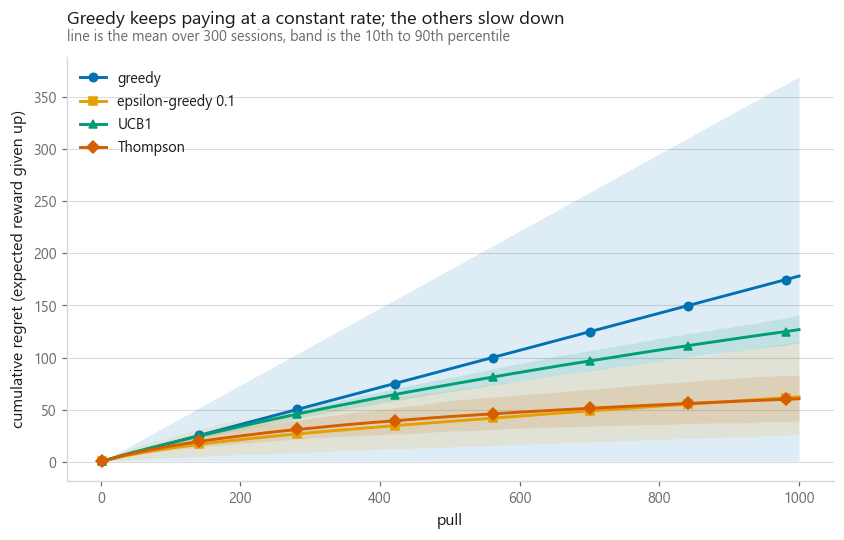

In [8]:
fig, ax = plt.subplots(figsize=(9.0, 5.0))
steps_axis = np.arange(1, STEPS + 1)

for i, (name, curve) in enumerate(curves.items()):
    low, high = np.percentile(curve, [10, 90], axis=0)
    ax.fill_between(steps_axis, low, high, color=style.PALETTE[i], alpha=0.13,
                    linewidth=0)
    ax.plot(steps_axis, curve.mean(axis=0), color=style.PALETTE[i], lw=1.9,
            marker=style.MARKERS[i], markevery=140, label=name)

ax.set_xlabel("pull")
ax.set_ylabel("cumulative regret (expected reward given up)")
ax.legend(loc="upper left")
style.title(ax, "Greedy keeps paying at a constant rate; the others slow down",
            "line is the mean over 300 sessions, band is the 10th to 90th percentile")
style.save(fig, FIG / "fig-02-regret.png")

In [9]:
summary = pd.DataFrame({
    "mean regret": [c[:, -1].mean() for c in curves.values()],
    "10th pct": [np.percentile(c[:, -1], 10) for c in curves.values()],
    "90th pct": [np.percentile(c[:, -1], 90) for c in curves.values()],
    "best arm, last 100 pulls": [(chosen[n][:, -100:] == BEST).mean()
                                 for n in curves],
}, index=list(curves))

print(f"after {STEPS} pulls, across {RUNS} sessions\n")
print(summary.round(2).to_string())

after 1000 pulls, across 300 sessions

                    mean regret  10th pct  90th pct  best arm, last 100 pulls
greedy                   178.16      0.55    369.52                      0.13
epsilon-greedy 0.1        62.26     26.14    114.92                      0.57
UCB1                     126.75    113.94    140.56                      0.37
Thompson                  60.42     39.35     83.29                      0.71


The band is the part to read. Reporting only the mean would hide the most
interesting thing about greedy, which is that its sessions do not resemble each
other at all: some lock onto the best arm immediately and coast, others lock
onto a poor arm and bleed at a fixed rate for the rest of the session. The mean
sits in a gap between two outcomes that mostly do not happen.

Here is the lock-in measured directly.

In [10]:
greedy_runs = chosen["greedy"]
distinct = np.array([np.unique(run).size for run in greedy_runs])
settled = np.array([np.bincount(run, minlength=K).argmax() for run in greedy_runs])

print(f"greedy pulled {distinct.mean():.1f} distinct arms per session, out of {K}")
print(f"it settled on the best arm in {(settled == BEST).mean():.0%} of sessions")
print(f"it settled on a below-median arm in "
      f"{(RATES[settled] < np.median(RATES)).mean():.0%} of sessions\n")

for name, c in chosen.items():
    print(f"{name:<20} distinct arms pulled per session: "
          f"{np.mean([np.unique(run).size for run in c]):5.1f}")

greedy pulled 2.2 distinct arms per session, out of 10
it settled on the best arm in 13% of sessions
it settled on a below-median arm in 39% of sessions

greedy               distinct arms pulled per session:   2.2
epsilon-greedy 0.1   distinct arms pulled per session:  10.0
UCB1                 distinct arms pulled per session:  10.0
Thompson             distinct arms pulled per session:  10.0


share of sessions on the best arm at the final pull
  greedy               13%
  epsilon-greedy 0.1   57%
  UCB1                 37%
  Thompson             70%


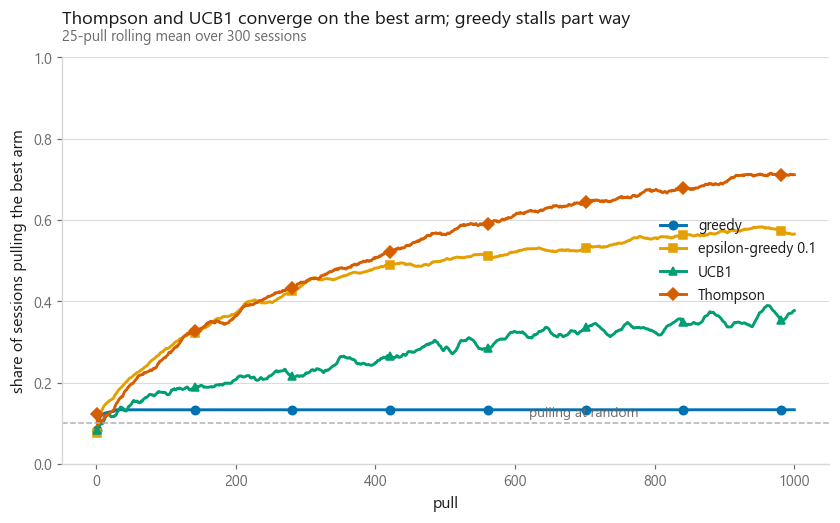

In [11]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))

for i, (name, c) in enumerate(chosen.items()):
    share = pd.Series(optimal_fraction(c, schedule)).rolling(25, min_periods=1).mean()
    ax.plot(steps_axis, share, color=style.PALETTE[i], lw=1.9,
            marker=style.MARKERS[i], markevery=140, label=name)

ax.axhline(0.1, color=style.NEUTRAL, lw=1.0, ls="--")
ax.annotate("pulling at random", xy=(STEPS * 0.62, 0.115), fontsize=9,
            color=style.MUTED)
ax.set_ylim(0, 1)
ax.set_xlabel("pull")
ax.set_ylabel("share of sessions pulling the best arm")
ax.legend(loc="center right")
style.title(ax, "Thompson and UCB1 converge on the best arm; greedy stalls part way",
            "25-pull rolling mean over 300 sessions")
style.save(fig, FIG / "fig-03-optimal-action.png")

print("share of sessions on the best arm at the final pull")
for name, c in chosen.items():
    print(f"  {name:<20} {optimal_fraction(c, schedule)[-1]:.0%}")

Two things in that chart surprised me the first time I plotted it.

Epsilon-greedy has a ceiling it cannot pass, and the ceiling is
$1 - \varepsilon(k-1)/k$. Even a strategy that has completely solved the problem
still spends epsilon of its pulls at random, and most random pulls land on a bad
arm. Its curve flattens well below the top of the chart, on purpose, by
construction.

UCB1 starts badly. Its first $k$ pulls are a forced round robin through every
arm, and for a while afterwards the $\sqrt{\log t / n}$ bonus is large enough to
keep dragging it back to arms it has already dismissed. It is buying information
early and cashing it in later, and on a longer horizon that trade pays.

### Sweeping epsilon

Epsilon is the only dial here with an obvious wrong answer in both directions, so
it is worth seeing the whole curve. Note that $\varepsilon = 0$ is plain greedy.

epsilon  mean regret  spread (90th - 10th)
      0        172.4                 369.0
   0.01        108.9                 224.4
   0.05         63.7                 114.2
    0.1         62.3                  88.8
    0.3         87.9                  44.4


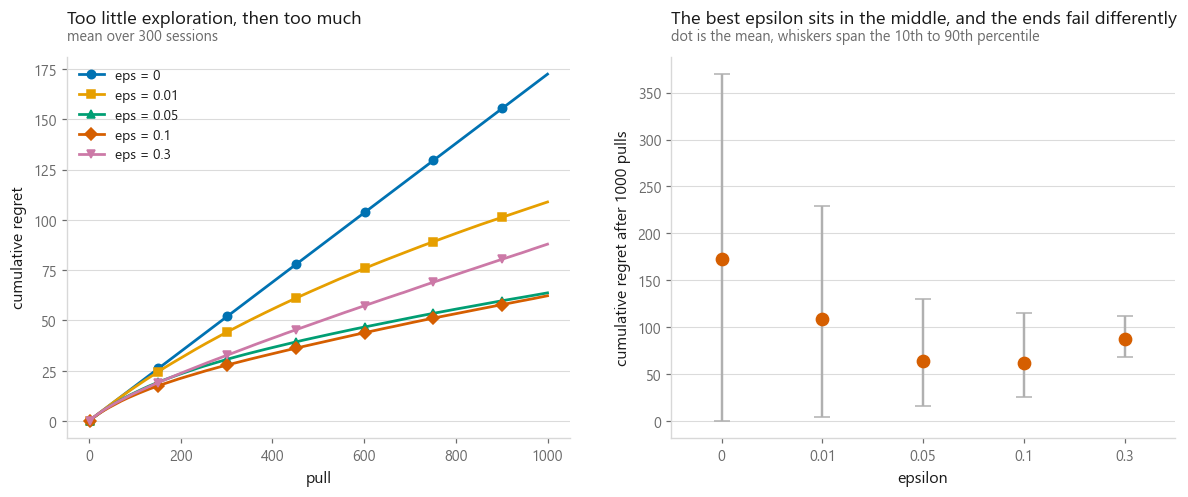

In [12]:
EPSILONS = [0.0, 0.01, 0.05, 0.1, 0.3]
sweep = run_all(
    {f"{e:g}": (lambda k, r, g, e=e: EpsilonGreedy(k, r, g, epsilon=e))
     for e in EPSILONS},
    stationary, STEPS,
)
sweep_curves = {name: regret(c, schedule) for name, c in sweep.items()}

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.5))

for i, (name, curve) in enumerate(sweep_curves.items()):
    axes[0].plot(steps_axis, curve.mean(axis=0), color=style.PALETTE[i], lw=1.8,
                 marker=style.MARKERS[i], markevery=150, label=f"eps = {name}")
axes[0].set_xlabel("pull")
axes[0].set_ylabel("cumulative regret")
axes[0].legend(loc="upper left", fontsize=9)
style.title(axes[0], "Too little exploration, then too much",
            "mean over 300 sessions")

finals = np.array([sweep_curves[n][:, -1] for n in sweep_curves])
mean_final = finals.mean(axis=1)
low = mean_final - np.percentile(finals, 10, axis=1)
high = np.percentile(finals, 90, axis=1) - mean_final
positions = np.arange(len(EPSILONS))

axes[1].errorbar(positions, mean_final, yerr=[low, high], fmt="o", ms=8,
                 color=style.HIGHLIGHT, ecolor=style.NEUTRAL, elinewidth=1.6,
                 capsize=5, lw=0)
axes[1].set_xticks(positions)
axes[1].set_xticklabels([f"{e:g}" for e in EPSILONS])
axes[1].set_xlim(-0.5, len(EPSILONS) - 0.5)
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel(f"cumulative regret after {STEPS} pulls")
style.title(axes[1], "The best epsilon sits in the middle, and the ends fail differently",
            "dot is the mean, whiskers span the 10th to 90th percentile")
style.save(fig, FIG / "fig-04-epsilon-sweep.png")

print(pd.DataFrame({
    "epsilon": [f"{e:g}" for e in EPSILONS],
    "mean regret": mean_final,
    "spread (90th - 10th)": np.percentile(finals, 90, axis=1)
                            - np.percentile(finals, 10, axis=1),
}).round(1).to_string(index=False))

The two ends fail in different ways, and the whiskers say it better than the
means do.

At the low end the average is bad because the *variance* is enormous. Those
sessions are not mediocre, they are bimodal: some found the best arm and paid
almost nothing, the rest locked onto something poor and paid all session. At the
high end the average is bad and the variance is small, because every session
reliably wastes the same fixed share of its pulls. One end gambles, the other
end pays a subscription.

The middle is where the curve bottoms out, and where it bottoms out depends on
the horizon. A thousand pulls wants more exploration than a hundred, because
there is more remaining budget to spend the knowledge on. This is why decaying
epsilon over time is the usual practical answer, and why UCB1 and Thompson,
which shrink their own exploration as evidence accumulates, need no dial here at
all.

## 5. When the world changes underneath you

Everything above assumed the arms are fixed. Real ones are not. Ad slots go
stale, users change their minds, a competitor changes their prices. So here is
the same bandit with one modification: partway through the session I reverse the
list of rates. The arm that was best becomes mediocre, and an arm that was
mediocre becomes best. Nothing announces the change.

This breaks something specific. The $1/n$ step size weights every reward the arm
ever produced equally, which is correct only if the arm's rate never moved. After
800 pulls a fresh reward shifts the estimate by one part in 800. The arm the
strategy trusts most is the arm it has pulled most, so it is also the arm whose
estimate is now the hardest to move, exactly backwards from what the situation
needs.

The fix is to stop averaging over all history. Replace $1/n$ with a constant
$\alpha$:

$$Q(a) \leftarrow Q(a) + \alpha\Big[R - Q(a)\Big]$$

Unrolling that shows what it does. The weight on a reward from $j$ pulls ago is
$\alpha(1-\alpha)^{j}$, so influence decays geometrically and the estimate is an
exponentially weighted average with a memory of roughly $1/\alpha$ pulls. It
never fully converges (that is the cost, and on a stationary problem it is a
real one), but it also never stops being able to change its mind.

Thompson has the same disease and the same cure. A posterior built from hundreds
of observations is narrow and stubborn, so I fade the counts back toward the
Beta(1, 1) prior by a factor each step. That is a constant step size wearing
Bayesian clothing.

In [13]:
DRIFT_STEPS, SWITCH = 2000, 1000
RATES_AFTER = RATES[::-1].copy()


class SwitchingBandit(Bandit):
    """The same ten arms, with the rates reversed once, partway through."""

    def __init__(self, rates, rates_after, switch_at, runs, seed):
        super().__init__(rates, runs, seed)
        self.rates_after = np.asarray(rates_after, dtype=float)
        self.switch_at = switch_at

    def rates_at(self, t):
        return self.rates_after if t > self.switch_at else self.rates


print(f"before the switch, best arm is {RATES.argmax()} at {RATES.max():.2f}")
print(f"after the switch,  best arm is {RATES_AFTER.argmax()} at {RATES_AFTER.max():.2f}")
print(f"the old best arm now pays {RATES_AFTER[BEST]:.2f}")

before the switch, best arm is 6 at 0.65
after the switch,  best arm is 3 at 0.65
the old best arm now pays 0.50


In [14]:
DRIFT_STRATEGIES = {
    "epsilon-greedy, 1/n":       lambda k, r, g: EpsilonGreedy(k, r, g, epsilon=0.1),
    "epsilon-greedy, alpha 0.1": lambda k, r, g: EpsilonGreedy(k, r, g, epsilon=0.1,
                                                               alpha=0.1),
    "UCB1":                      lambda k, r, g: UCB1(k, r, g),
    "Thompson":                  lambda k, r, g: Thompson(k, r, g),
    "Thompson, decay 0.99":      lambda k, r, g: Thompson(k, r, g, decay=0.99),
}

switching = lambda: SwitchingBandit(RATES, RATES_AFTER, SWITCH, RUNS, SEED)
drift_chosen = run_all(DRIFT_STRATEGIES, switching, DRIFT_STEPS)
drift_schedule = switching().schedule(DRIFT_STEPS)
drift_curves = {n: regret(c, drift_schedule) for n, c in drift_chosen.items()}

print(f"done: {len(DRIFT_STRATEGIES)} strategies x {RUNS} sessions x {DRIFT_STEPS} pulls")

done: 5 strategies x 300 sessions x 2000 pulls


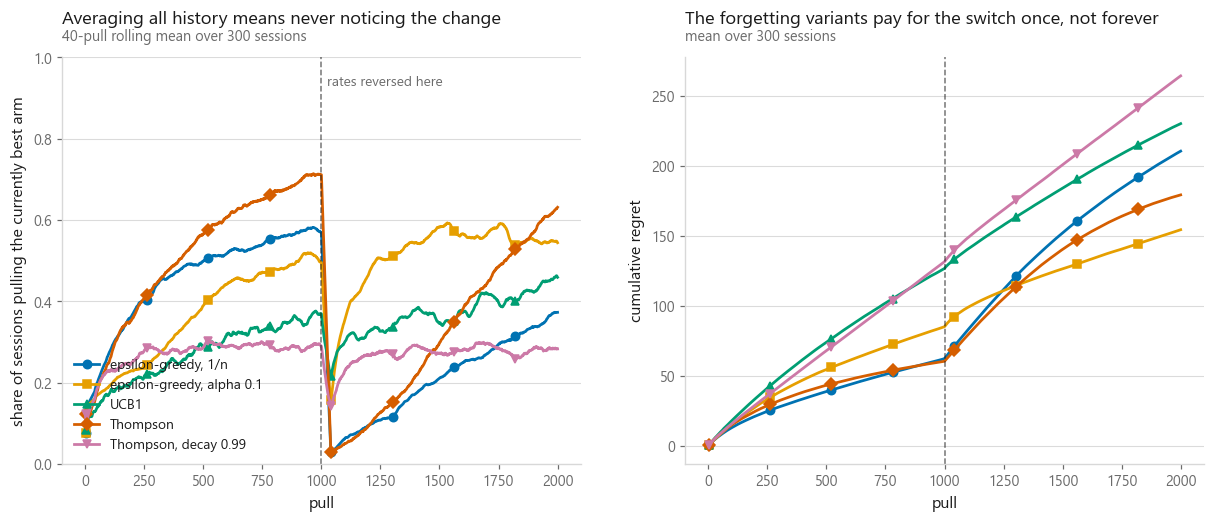

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))
drift_axis = np.arange(1, DRIFT_STEPS + 1)

for i, (name, c) in enumerate(drift_chosen.items()):
    share = pd.Series(optimal_fraction(c, drift_schedule)).rolling(
        40, min_periods=1).mean()
    axes[0].plot(drift_axis, share, color=style.PALETTE[i], lw=1.8,
                 marker=style.MARKERS[i], markevery=260, label=name)
    axes[1].plot(drift_axis, drift_curves[name].mean(axis=0), color=style.PALETTE[i],
                 lw=1.8, marker=style.MARKERS[i], markevery=260, label=name)

for ax in axes:
    ax.axvline(SWITCH, color=style.INK, lw=1.0, ls="--", alpha=0.6)
    ax.set_xlabel("pull")

axes[0].annotate("rates reversed here", xy=(SWITCH + 25, 0.93), fontsize=9,
                 color=style.MUTED)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("share of sessions pulling the currently best arm")
axes[0].legend(loc="lower left", fontsize=9)
style.title(axes[0], "Averaging all history means never noticing the change",
            "40-pull rolling mean over 300 sessions")

axes[1].set_ylabel("cumulative regret")
style.title(axes[1], "The forgetting variants pay for the switch once, not forever",
            "mean over 300 sessions")
style.save(fig, FIG / "fig-05-non-stationary.png")

In [16]:
recovery = pd.DataFrame({
    "on best arm, just before switch": [
        optimal_fraction(c, drift_schedule)[SWITCH - 50:SWITCH].mean()
        for c in drift_chosen.values()],
    "on best arm, 200 pulls after": [
        optimal_fraction(c, drift_schedule)[SWITCH + 150:SWITCH + 250].mean()
        for c in drift_chosen.values()],
    "on best arm, at the end": [
        optimal_fraction(c, drift_schedule)[-100:].mean()
        for c in drift_chosen.values()],
    "regret in the second half": [
        (c[:, -1] - c[:, SWITCH - 1]).mean() for c in drift_curves.values()],
}, index=list(drift_chosen))

print(recovery.round(2).to_string())

                           on best arm, just before switch  on best arm, 200 pulls after  on best arm, at the end  regret in the second half
epsilon-greedy, 1/n                                   0.57                          0.10                     0.36                     148.35
epsilon-greedy, alpha 0.1                             0.50                          0.48                     0.54                      69.31
UCB1                                                  0.37                          0.33                     0.45                     103.52
Thompson                                              0.71                          0.11                     0.62                     118.91
Thompson, decay 0.99                                  0.29                          0.27                     0.28                     132.81


The right-hand panel is the summary: after the switch, some of the lines bend
once and then flatten again, and some carry on rising in a straight line. A
straight line after the switch means the strategy never recovered at all: it is
still confidently pulling an arm that stopped being good.

What I take from this is less about bandits than about evaluation. Every one of
these strategies looked fine in section 4. The stationary benchmark had no way to
tell them apart on the one property that decides whether they survive contact
with a real system. If your simulator never changes its mind, it cannot tell you
which of your methods can.

The constant step size has a real cost, and it is worth being straight about it:
it throws away information. On a genuinely fixed problem, $1/n$ converges and
$\alpha$ jitters around the answer forever. You are buying the ability to adapt,
and you pay for it in precision. How much to pay is the same question as how fast
you think the world moves.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Each choice pays off immediately and does not change what comes next: A/B tests, ad slots, treatment arms, which model to route a request to |
| **Avoid it when** | Actions have consequences that arrive later or change the situation. That needs [MDPs](../03-markov-decision-processes/) and [Q-learning](../04-q-learning/) |
| **Greedy** | Never use it. It stops collecting the evidence that would correct it |
| **Epsilon-greedy** | One line, works, linear regret. Decay epsilon over time and it becomes respectable |
| **UCB1** | Deterministic, no tuning beyond `c`, logarithmic regret. Wants bounded rewards and a stationary world |
| **Thompson** | Usually the best of the four in practice, handles delayed and batched feedback gracefully, needs a conjugate prior or a sampler |
| **Non-stationary** | Replace `1/n` with a constant step, or discount the posterior counts. Sliding-window UCB is the equivalent patch for UCB1 |
| **Watch out** | Regret against a fixed benchmark is meaningless once the benchmark moves. Score against the best arm *at each step* |
| **Next** | [MDPs](../03-markov-decision-processes/), where actions start having consequences |

## What to remember

1. A bandit is reinforcement learning with the sequence removed. What survives
   the removal is the explore-exploit tradeoff, which means that tradeoff is the
   irreducible part.
2. Score regret, not reward. Reward measures the machines; regret measures the
   strategy.
3. Linear regret is the failure signature. A strategy that keeps a fixed chance
   of pulling a bad arm pays a toll every step forever.
4. Greedy fails because its choice destroys the evidence that would have changed
   it. Estimates only improve for arms you actually pull.
5. UCB1 judges each arm by its best plausible case, so a pull is either
   profitable or informative. Thompson pulls each arm with the probability that
   it is the best one. Both shrink their own exploration as evidence arrives,
   which is why neither needs an epsilon.
6. Report the spread across runs, not the mean. Greedy's mean regret describes
   an outcome that mostly does not occur.
7. Averaging all of history is an assumption that the world is fixed. A constant
   step size drops that assumption and buys the ability to change your mind,
   paying for it in precision.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [11-03 Markov decision processes](../03-markov-decision-processes/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#ReinforcementLearning` `#MultiArmedBandit` `#ThompsonSampling` `#UCB`
`#ExploreExploit` `#MachineLearning` `#Python` `#NumPy` `#MLTutorial`
`#LearnMachineLearning` `#AI`